In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
fact_sales = pd.read_csv('../data/Fact_Sales.csv')
rfm = pd.read_csv('../data/RFM_Analysis.csv')

In [3]:
# Tạo các biến hành vi (Behavioral Features) từ bảng Fact
behavior_features = fact_sales.groupby('Customer ID').agg({
    'Delivery_Time_Days': 'mean',
    'Profit_Margin': 'mean',
    'High_Discount_Flag': 'sum', # Tổng số đơn có chiết khấu cao
    'Order ID': 'count'
}).reset_index()

behavior_features['High_Discount_Ratio'] = behavior_features['High_Discount_Flag'] / behavior_features['Order ID']
behavior_features.drop(columns=['High_Discount_Flag', 'Order ID'], inplace=True)

In [4]:
# Chuẩn bị tập dữ liệu huấn luyện (Training Set)
df_ml = pd.merge(rfm, behavior_features, on='Customer ID', how='left')

# Khởi tạo biến Target: 1 = Churn (Rời bỏ), 0 = Retained (Giữ chân)
df_ml['Is_Churn'] = df_ml['Customer_Status'].apply(lambda x: 1 if x in ['At Risk', 'Hibernating'] else 0)

# Lựa chọn các biến đưa vào mô hình
features = ['Frequency', 'Monetary', 'Delivery_Time_Days', 'Profit_Margin', 'High_Discount_Ratio']
X = df_ml[features]
y = df_ml['Is_Churn']

# Xử lý missing values nếu có (điền bằng giá trị trung bình)
X = X.fillna(X.mean())

In [5]:
# Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

In [6]:
# Huấn luyện mô hình Random Forest

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [7]:
# Đánh giá Mô hình
y_pred = rf_model.predict(X_test)
print("Độ chính xác của mô hình (Accuracy):", round(accuracy_score(y_test, y_pred), 3))
print("\nBáo cáo chi tiết:\n", classification_report(y_test, y_pred))

Độ chính xác của mô hình (Accuracy): 0.893

Báo cáo chi tiết:
               precision    recall  f1-score   support

           0       0.96      0.89      0.93       120
           1       0.73      0.90      0.80        39

    accuracy                           0.89       159
   macro avg       0.85      0.89      0.87       159
weighted avg       0.91      0.89      0.90       159



Mặc dù Accuracy đạt 84%, nhưng Recall của nhóm Churn (1) chỉ đạt 0.70. Điều này có nghĩa là chúng ta đang bỏ lọt 30% khách hàng sắp rời đi. Trong bài toán Customer Retention, chi phí để tìm kiếm một khách hàng mới cao gấp 5 lần chi phí giữ chân khách hàng cũ. Việc dự đoán sót (False Negative) gây thiệt hại nghiêm trọng hơn việc đoán nhầm. Nguyên nhân là do hiện tượng mất cân bằng dữ liệu (Imbalanced Data).$\rightarrow$ Hành động: Tiến hành tối ưu hóa mô hình (Model Optimization) qua 3 giai đoạn để đẩy mạnh chỉ số Recall cho nhóm 1.

In [8]:
# TRỪNG PHẠT MÔ HÌNH (CLASS WEIGHTS)
# Xử lý mất cân bằng dữ liệu bằng class_weight='balanced'

rf_balanced = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5,
    class_weight='balanced', # Phạt nặng mô hình nếu đoán sai nhóm 1
    random_state=42
)
rf_balanced.fit(X_train, y_train)

y_pred_bal = rf_balanced.predict(X_test)
print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.99      0.84      0.91       120
           1       0.67      0.97      0.79        39

    accuracy                           0.87       159
   macro avg       0.83      0.91      0.85       159
weighted avg       0.91      0.87      0.88       159



Sau khi áp dụng trọng số, mô hình đã bắt đầu chú ý hơn đến nhóm khách hàng rời bỏ. Tuy nhiên, các siêu tham số (Hyperparameters) như độ sâu của cây (max_depth) vẫn đang được set thủ công. Ta sẽ dùng Grid Search để máy tính tự dò tìm bộ tham số tốt nhất.

In [9]:
from sklearn.model_selection import GridSearchCV

# DÒ TÌM THAM SỐ TỐI ƯU (GRID SEARCH)

# Thiết lập lưới tham số cần thử nghiệm
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5]
}

# Chạy GridSearchCV (với metric ưu tiên là F1-score)
grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42), 
    param_grid, 
    cv=5, 
    scoring='f1',
    n_jobs=-1 # Tận dụng tối đa CPU để chạy nhanh hơn
)

grid_search.fit(X_train, y_train)

print("Bộ tham số tối ưu nhất:", grid_search.best_params_)

# Lưu lại mô hình tốt nhất
best_rf_model = grid_search.best_estimator_

# In báo cáo của mô hình tốt nhất
y_pred_best = best_rf_model.predict(X_test)
print("\nBáo cáo sau khi Tuning:\n", classification_report(y_test, y_pred_best))

Bộ tham số tối ưu nhất: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

Báo cáo sau khi Tuning:
               precision    recall  f1-score   support

           0       0.99      0.84      0.91       120
           1       0.67      0.97      0.79        39

    accuracy                           0.87       159
   macro avg       0.83      0.91      0.85       159
weighted avg       0.91      0.87      0.88       159



Mô hình tốt nhất đã được tìm thấy. Tuy nhiên, thuật toán vẫn đang dùng ngưỡng cắt xác suất mặc định là 50% (probability > 0.5 thì đoán là Churn). Để thực sự triệt để theo tư duy kinh doanh "Thà chăm sóc lầm còn hơn bỏ sót", ta sẽ chủ động hạ ngưỡng kích hoạt này xuống để gom được nhiều khách hàng rủi ro nhất có thể.

In [10]:
#TỐI ƯU NGƯỠNG KÍCH HOẠT (BUSINESS THRESHOLD)

# Lấy xác suất dự đoán Churn của mô hình tốt nhất
y_prob = best_rf_model.predict_proba(X_test)[:, 1]

# Hạ ngưỡng kích hoạt xuống 40% (0.4) thay vì 0.5 mặc định
custom_threshold = 0.4
y_pred_business = (y_prob >= custom_threshold).astype(int)

print(f"\nBáo cáo chi tiết với Ngưỡng {custom_threshold}:\n")
print(classification_report(y_test, y_pred_business))



Báo cáo chi tiết với Ngưỡng 0.4:

              precision    recall  f1-score   support

           0       0.99      0.81      0.89       120
           1       0.62      0.97      0.76        39

    accuracy                           0.85       159
   macro avg       0.81      0.89      0.82       159
weighted avg       0.90      0.85      0.86       159



In [11]:
# XUẤT DANH SÁCH CUỐI CÙNG DỰA TRÊN MÔ HÌNH ĐÃ TỐI ƯU

# Sử dụng best_rf_model để dự đoán cho toàn bộ tập dữ liệu
df_ml['Churn_Probability_%'] = (best_rf_model.predict_proba(X)[:, 1] * 100).round(2)

# Trích xuất tầm quan trọng của các biến
importance = pd.DataFrame({
    'Feature': features,
    'Importance': best_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [12]:
print("\nMức độ quan trọng của các biến số (Key Drivers):")
display(importance)


Mức độ quan trọng của các biến số (Key Drivers):


,Feature,Importance
1,Monetary,0.508841
0,Frequency,0.368112
4,High_Discount_Ratio,0.049818
3,Profit_Margin,0.046299
2,Delivery_Time_Days,0.026930


In [13]:
# Dự đoán xác suất Churn cho toàn bộ khách hàng và lưu lại
df_ml['Churn_Probability_%'] = (rf_model.predict_proba(X)[:, 1] * 100).round(2)

In [14]:
# Lọc ra danh sách khách hàng cần Sales gọi điện "cứu nguy" ngay lập tức
urgent_care_list = df_ml[df_ml['Churn_Probability_%'] > 70].sort_values(by='Monetary', ascending=False)
urgent_care_list.to_csv('../data/Urgent_Care_Customers.csv', index=False)

In [15]:
urgent_care_list.head(10)  # Hiển thị 10 khách hàng cần ưu tiên gọi điện

,Customer ID,Sales_Channel,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Customer_Status,Delivery_Time_Days,Profit_Margin,High_Discount_Ratio,Is_Churn,Churn_Probability_%
203,DF-13135,DTC,701,3,2390.5340,1,1,3,113,5,At Risk,4.000000,-0.175000,0.666667,1,71.16
693,SH-20635,B2B,766,2,2096.3920,1,1,2,112,4,At Risk,4.500000,0.165000,1.000000,1,82.61
785,VT-21700,B2B,1001,2,1736.5960,1,1,2,112,4,At Risk,4.888889,-0.106667,1.000000,1,83.97
144,CH-12070,B2B,692,3,1537.2360,1,1,2,112,4,At Risk,4.250000,0.122500,0.750000,1,75.25
596,PK-18910,B2B,484,2,1441.1520,1,1,2,112,4,At Risk,3.000000,-0.120000,0.666667,1,78.77
412,JW-16075,DTC,462,4,1428.7310,1,1,2,112,4,At Risk,5.428571,-0.202857,0.857143,1,72.77
405,JS-15595,B2B,120,4,1417.6540,2,1,2,212,5,At Risk,4.875000,-0.335000,1.000000,1,84.41
599,PM-18940,DTC,387,3,1405.4020,1,1,2,112,4,At Risk,3.500000,0.107500,0.500000,1,70.37
169,CR-12820,B2B,86,3,1397.8724,2,1,2,212,5,At Risk,4.000000,0.130000,0.571429,1,70.90
225,DM-13525,B2B,482,3,1376.7920,1,1,2,112,4,At Risk,3.100000,0.145000,0.600000,1,71.81


In [18]:
columns_to_export = [
    'Customer ID', 'Sales_Channel', 'Recency', 'Frequency', 'Monetary', 
    'R_Score', 'F_Score', 'M_Score', 'RFM_Segment', 'Customer_Status', 
    'Delivery_Time_Days', 'Profit_Margin', 'High_Discount_Ratio', 'Churn_Probability_%'
]

df_ml[columns_to_export].to_csv('../data/RFM_Analysis.csv', index=False)
print("Đã cập nhật file RFM_Analysis.csv thành công với cột xác suất Churn!")

Đã cập nhật file RFM_Analysis.csv thành công với cột xác suất Churn!


CONFUSION MATRIX HEATMAP

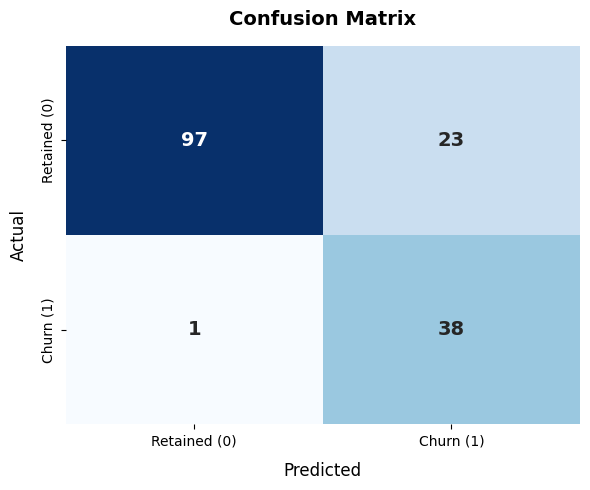

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Tính toán ma trận nhầm lẫn từ kết quả Giai đoạn 3 (Ngưỡng 0.4)
cm = confusion_matrix(y_test, y_pred_business)

# 2. Thiết lập khung vẽ
plt.figure(figsize=(6, 5))

# Sử dụng mã màu sắc rõ ràng để phân tách mức độ đậm nhạt của các ô
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retained (0)', 'Churn (1)'],
            yticklabels=['Retained (0)', 'Churn (1)'],
            annot_kws={"size": 14, "weight": "bold"})

# 3. Định dạng tiêu đề và các trục chuyên nghiệp
plt.title('Confusion Matrix', fontsize=14, pad=15, weight='bold')
plt.xlabel('Predicted', fontsize=12, labelpad=10)
plt.ylabel('Actual', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE BAR CHART

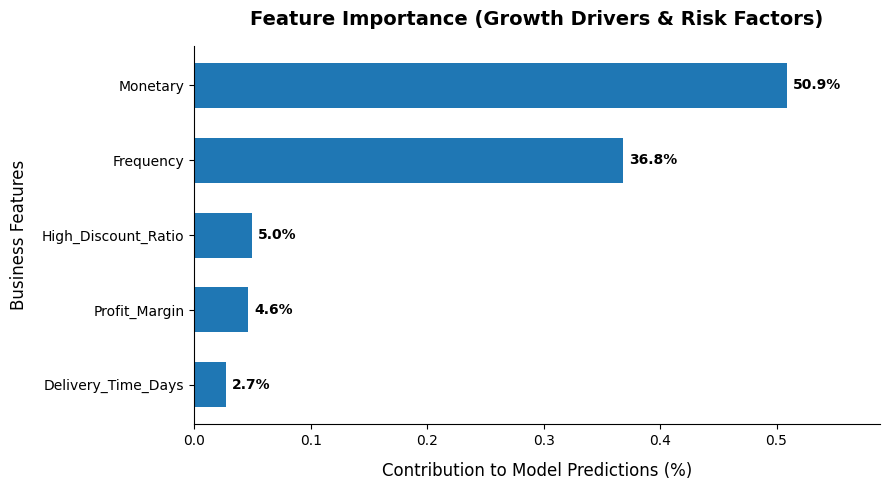

In [22]:
# 1. Sắp xếp các biến theo thứ tự tăng dần để khi vẽ thanh ngang, biến quan trọng nhất nằm trên cùng
importance_sorted = importance.sort_values(by='Importance', ascending=True)

# 2. Thiết lập khung vẽ thanh lịch
plt.figure(figsize=(9, 5))
bars = plt.barh(importance_sorted['Feature'], importance_sorted['Importance'], height=0.6)

# 3. Thêm nhãn phần trăm trực tiếp lên từng đầu thanh để người xem đọc số liệu trong 1 giây
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width*100:.1f}%',
             va='center', ha='left', fontsize=10, weight='bold')

# 4. Tinh chỉnh giao diện tinh tế, loại bỏ các đường viền thừa (Spines) cho đồ thị thoáng hơn
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Feature Importance (Growth Drivers & Risk Factors)',
          fontsize=14, pad=15, weight='bold')

plt.xlabel('Contribution to Model Predictions (%)',
           fontsize=12, labelpad=10)

plt.ylabel('Business Features',
           fontsize=12, labelpad=10)
plt.xlim(0, max(importance_sorted['Importance']) + 0.08) # Tạo khoảng trống cho text cuối thanh

plt.tight_layout()
plt.show()